# Plot Ridge coefficients as a function of the regularization

该示例演示多重共线性对模型估计器系数产生的影响。

本例选用岭回归作为模型估计器。图中每条颜色曲线分别代表系数向量中的一个特征，纵轴系数值随横轴正则化参数的变化趋势被可视化呈现。

该案例同时证明，岭回归非常适用于条件数极差的矩阵。对于这类矩阵，目标变量发生微小变动，就会导致求解得到的特征权重产生巨大方差。此时设置合适的正则化系数 $\alpha$，能够有效抑制这种波动（噪声干扰）。

当 $\alpha$ 取值极大时，正则化项的作用会远大于平方损失项，所有回归系数会趋近于 0。在曲线右端，随着 $\alpha$ 无限趋近于 0，模型解无限接近普通最小二乘结果，各系数会出现剧烈震荡。实际建模时，需要调优 $\alpha$，在拟合损失与正则约束之间取得平衡。

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

# X is the 10x10 Hilbert matrix
X = 1.0 / (np.arange(1, 11) + np.arange(0, 10)[:, np.newaxis])
y = np.ones(10)

## 计算路径

In [9]:
n_alphas = 200
alphas = np.logspace(-10, -2, n_alphas)

coefs = []
for a in alphas:
    ridge = linear_model.Ridge(alpha=a, fit_intercept=False)
    ridge.fit(x, y)
    coefs.append(ridge.coef_)

## 可视化结果

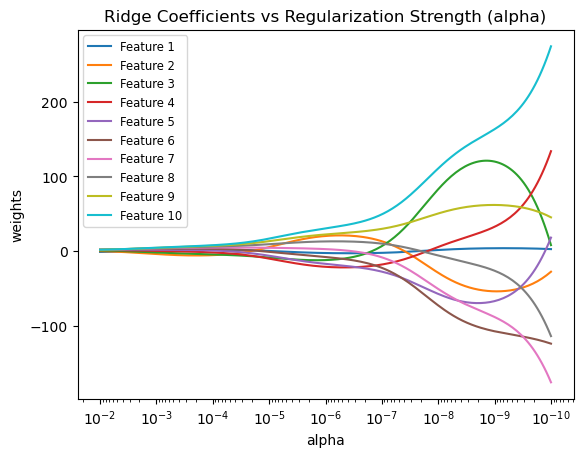

In [10]:
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge Coefficients vs Regularization Strength (alpha)")
plt.axis("tight")
plt.legend(
    [f"Feature {i + 1}" for i in range(X.shape[1])], loc="best", fontsize="small"
)
plt.show()